# Fruit Freshness Detection — CNN + Transfer Learning (MobileNetV2)

Dataset: Fruit Fresh and Rotten (Kaggle)

**Workflow:** EDA → Preprocessing → Baseline CNN → Transfer Learning (MobileNetV2) → Fine-tuning → Evaluation

> Update `DATA_DIR` below to point to wherever you extract the Kaggle dataset (e.g. after `kaggle datasets download` or manual upload).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('TF version:', tf.__version__)

TF version: 2.20.0


## 0. Download Dataset Directly from Kaggle (Colab)

Run this cell first in Colab. It uses `kagglehub`, which is pre-installed on Colab and handles authentication with a simple login prompt (no need to manually upload a `kaggle.json` file).

If prompted, it will open a Kaggle login/consent flow the first time — just follow it once per session.

In [2]:
import kagglehub

# Downloads and caches the dataset; returns the local path
dataset_path = kagglehub.dataset_download('koyaa123456/fruit-fresh-and-rotten')
print('Dataset downloaded to:', dataset_path)

import os
print(os.listdir(dataset_path))

100%|██████████| 1.45G/1.45G [00:20<00:00, 74.8MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/koyaa123456/fruit-fresh-and-rotten/versions/1
['traindata']


The printed listing above will show the folder structure inside `dataset_path` (likely a `traindata` folder containing the 12 class subfolders). Copy the exact path you see into `DATA_DIR` in the next section — e.g. `DATA_DIR = os.path.join(dataset_path, 'traindata')`.

## 1. Setup & Config

In [3]:
DATA_DIR = os.path.join(dataset_path, 'traindata')  # adjust subfolder name if kagglehub listing showed something different
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_BASELINE = 8
EPOCHS_TL = 10
EPOCHS_FINETUNE = 6

## 2. Exploratory Data Analysis
Check class names, counts per class, and a few sample images — this is a slide on its own.

Classes found: ['fresh_peaches_done', 'fresh_pomegranates_done', 'fresh_strawberries_done', 'freshapples', 'freshbanana', 'freshoranges', 'rotten_peaches_done', 'rotten_pomegranates_done', 'rotten_strawberries_done', 'rottenapples', 'rottenbanana', 'rottenoranges']
{'fresh_peaches_done': 250, 'fresh_pomegranates_done': 311, 'fresh_strawberries_done': 250, 'freshapples': 1693, 'freshbanana': 1581, 'freshoranges': 1466, 'rotten_peaches_done': 343, 'rotten_pomegranates_done': 250, 'rotten_strawberries_done': 251, 'rottenapples': 2342, 'rottenbanana': 2224, 'rottenoranges': 1595}


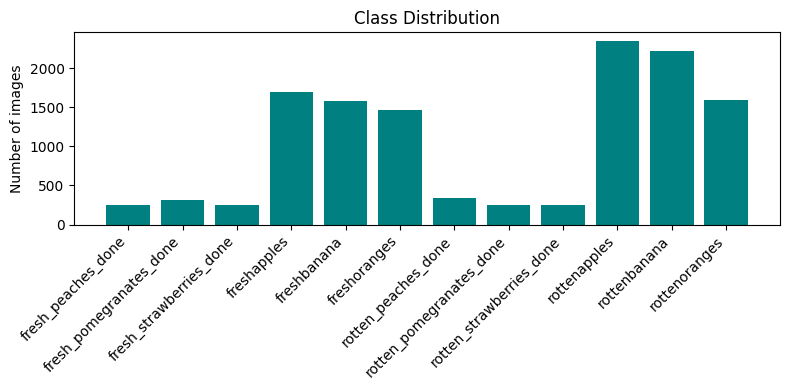

In [4]:
train_dir = DATA_DIR  # each subfolder here IS a class (12 classes total)
class_names = sorted(os.listdir(train_dir))
print('Classes found:', class_names)

counts = {}
for c in class_names:
    folder = os.path.join(train_dir, c)
    if os.path.isdir(folder):
        counts[c] = len(os.listdir(folder))
print(counts)

plt.figure(figsize=(8,4))
plt.bar(counts.keys(), counts.values(), color='teal')
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution')
plt.ylabel('Number of images')
plt.tight_layout()
plt.savefig('outputs_class_distribution.png', dpi=150)
plt.show()

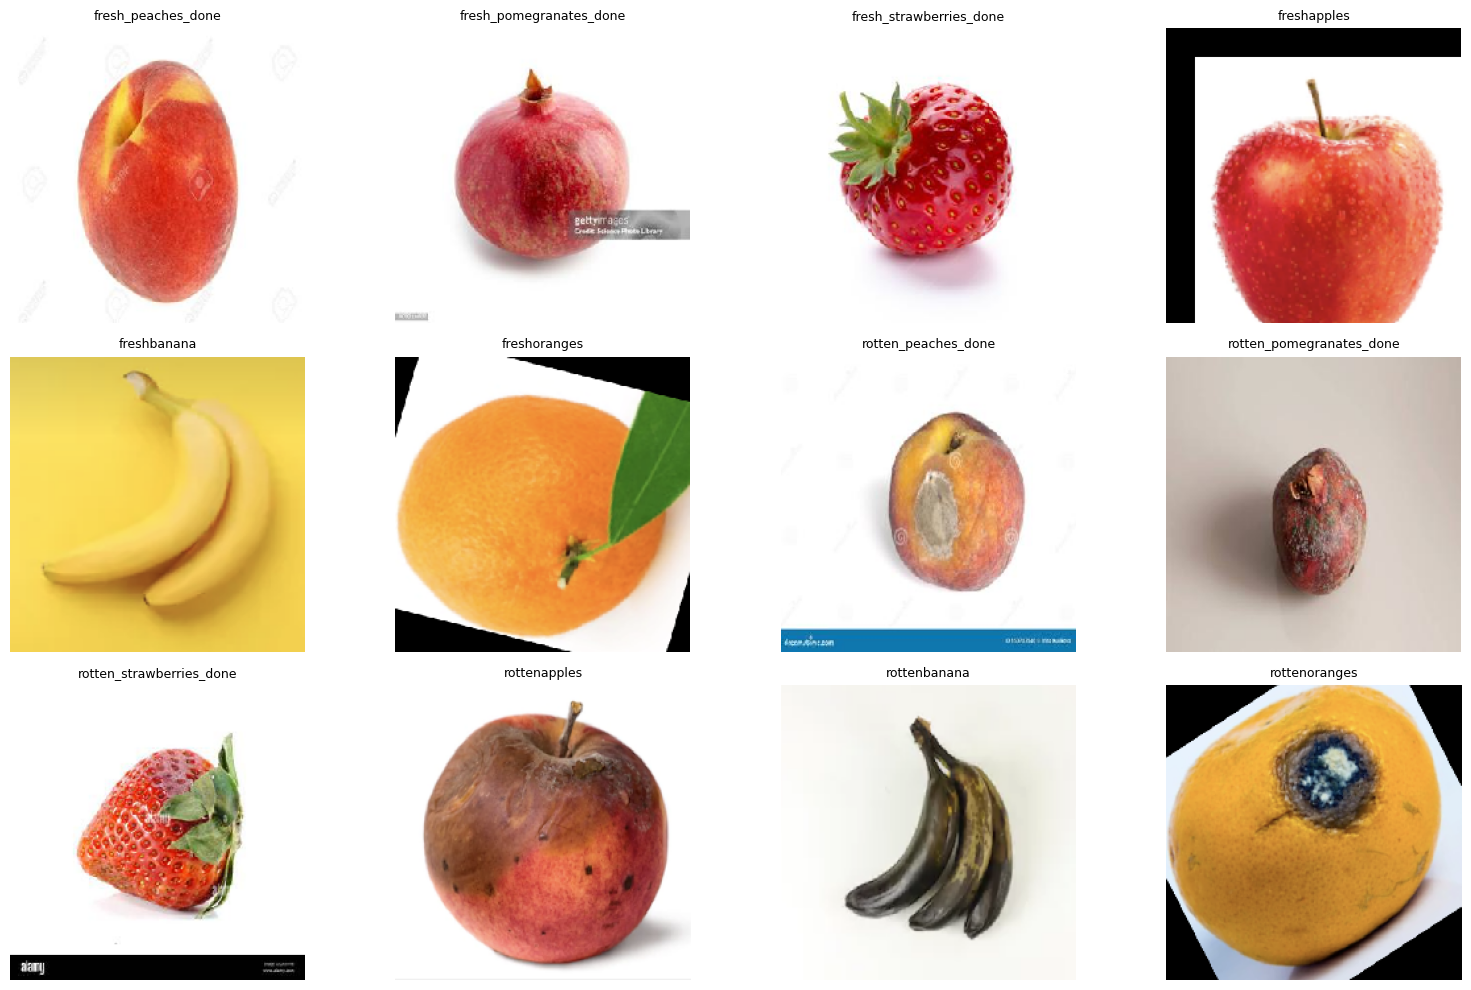

In [5]:
# Sample images grid (all 12 classes)
fig, axes = plt.subplots(3, 4, figsize=(16,10))
for ax, c in zip(axes.flatten(), class_names[:12]):
    folder = os.path.join(train_dir, c)
    img_name = os.listdir(folder)[0]
    img = tf.keras.preprocessing.image.load_img(os.path.join(folder, img_name), target_size=IMG_SIZE)
    ax.imshow(img)
    ax.set_title(c, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('outputs_sample_images.png', dpi=150)
plt.show()

## 3. Data Preprocessing & Augmentation

In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)

num_classes = train_gen.num_classes
print('Num classes:', num_classes)
print(train_gen.class_indices)

Found 10048 images belonging to 12 classes.
Found 2508 images belonging to 12 classes.
Num classes: 12
{'fresh_peaches_done': 0, 'fresh_pomegranates_done': 1, 'fresh_strawberries_done': 2, 'freshapples': 3, 'freshbanana': 4, 'freshoranges': 5, 'rotten_peaches_done': 6, 'rotten_pomegranates_done': 7, 'rotten_strawberries_done': 8, 'rottenapples': 9, 'rottenbanana': 10, 'rottenoranges': 11}


## 4. Baseline CNN (from scratch) — comparison point

In [7]:
def build_baseline_cnn(input_shape=(224,224,3), num_classes=num_classes):
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,508 (42.61 MB)

 Trainable params: 11,170,508 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_BASELINE
)

Epoch 1/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 172s 522ms/step - accuracy: 0.6741 - loss: 1.0074 - val_accuracy: 0.8158 - val_loss: 0.5461
Epoch 2/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 156s 496ms/step - accuracy: 0.7917 - loss: 0.6212 - val_accuracy: 0.8513 - val_loss: 0.4406
Epoch 3/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 156s 495ms/step - accuracy: 0.8178 - loss: 0.5319 - val_accuracy: 0.8720 - val_loss: 0.3585
Epoch 4/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 157s 501ms/step - accuracy: 0.8489 - loss: 0.4388 - val_accuracy: 0.8812 - val_loss: 0.3406
Epoch 5/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 154s 491ms/step - accuracy: 0.8587 - loss: 0.4210 - val_accuracy: 0.8931 - val_loss: 0.3194
Epoch 6/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 155s 495ms/step - accuracy: 0.8725 - loss: 0.3787 - val_accuracy: 0.8856 - val_loss: 0.3234
Epoch 7/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 202s 496ms/step - accuracy: 0.8779 - loss: 0.3513 - val_accuracy: 0.9163 - val_loss: 0.2459
Epoch 8/8
314/314 ━━━━━━━━━━━━━━━━━━━━ 157s 500ms/step - accuracy: 0.8877 - loss: 0

## 5. Transfer Learning — MobileNetV2 (frozen base)

In [9]:
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

tl_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,500 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy')

tl_history = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_TL,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.7867 - loss: 0.6877

314/314 ━━━━━━━━━━━━━━━━━━━━ 185s 535ms/step - accuracy: 0.8767 - loss: 0.3850 - val_accuracy: 0.9494 - val_loss: 0.1467
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9424 - loss: 0.1713

314/314 ━━━━━━━━━━━━━━━━━━━━ 149s 474ms/step - accuracy: 0.9454 - loss: 0.1615 - val_accuracy: 0.9717 - val_loss: 0.0928
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9581 - loss: 0.1263

314/314 ━━━━━━━━━━━━━━━━━━━━ 149s 475ms/step - accuracy: 0.9580 - loss: 0.1231 - val_accuracy: 0.9745 - val_loss: 0.0817
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 150s 477ms/step - accuracy: 0.9644 - loss: 0.1009 - val_accuracy: 0.9729 - val_loss: 0.0764
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9607 - loss: 0.1012

314/314 ━━━━━━━━━━━━━━━━━━━━ 152s 485ms/step - accuracy: 0.9687 - loss: 0.0869 - val_accuracy: 0.9793 - val_loss: 0.0658
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9749 - loss: 0.0739

314/314 ━━━━━━━━━━━━━━━━━━━━ 153s 487ms/step - accuracy: 0.9730 - loss: 0.0768 - val_accuracy: 0.9801 - val_loss: 0.0593
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 152s 484ms/step - accuracy: 0.9741 - loss: 0.0705 - val_accuracy: 0.9721 - val_loss: 0.0784
Epoch 8/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 153s 486ms/step - accuracy: 0.9763 - loss: 0.0655 - val_accuracy: 0.9785 - val_loss: 0.0615
Epoch 9/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 150s 478ms/step - accuracy: 0.9768 - loss: 0.0618 - val_accuracy: 0.9761 - val_loss: 0.0748


## 6. Fine-tuning — unfreeze last layers of MobileNetV2

In [11]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30  # unfreeze last 30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

tl_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

finetune_history = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 178s 517ms/step - accuracy: 0.8999 - loss: 0.3249 - val_accuracy: 0.9709 - val_loss: 0.0837
Epoch 2/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 154s 489ms/step - accuracy: 0.9511 - loss: 0.1405 - val_accuracy: 0.9757 - val_loss: 0.0688
Epoch 3/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 202s 490ms/step - accuracy: 0.9629 - loss: 0.1060 - val_accuracy: 0.9773 - val_loss: 0.0583
Epoch 4/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 153s 487ms/step - accuracy: 0.9678 - loss: 0.0976 - val_accuracy: 0.9781 - val_loss: 0.0541
Epoch 5/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9741 - loss: 0.0773

314/314 ━━━━━━━━━━━━━━━━━━━━ 155s 494ms/step - accuracy: 0.9711 - loss: 0.0824 - val_accuracy: 0.9813 - val_loss: 0.0489
Epoch 6/6
314/314 ━━━━━━━━━━━━━━━━━━━━ 154s 490ms/step - accuracy: 0.9709 - loss: 0.0782 - val_accuracy: 0.9813 - val_loss: 0.0456


## 7. Training Curves (Accuracy & Loss) — for PPT

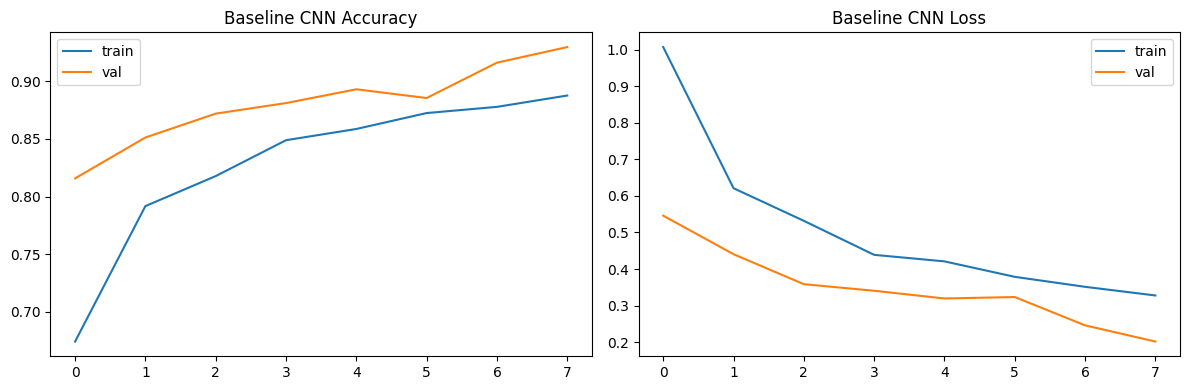

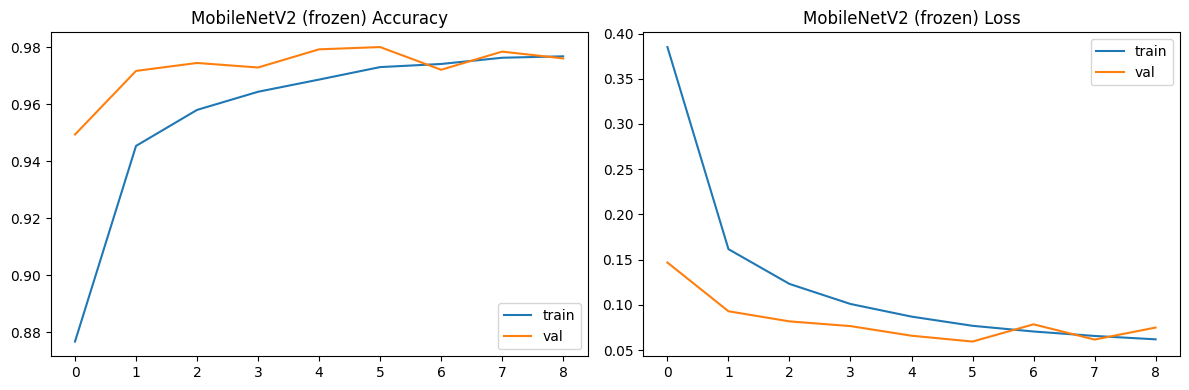

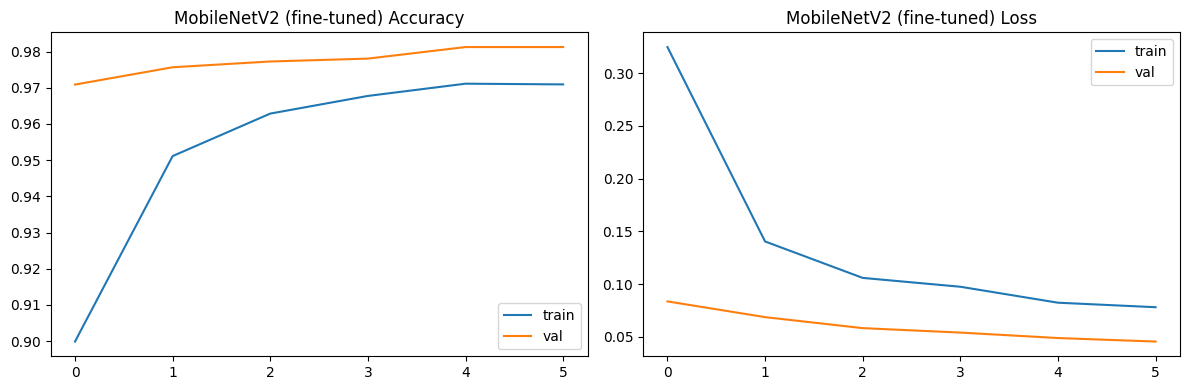

In [12]:
def plot_history(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title(f'{title_prefix} Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title(f'{title_prefix} Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'outputs_{title_prefix.lower().replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

plot_history(baseline_history, 'Baseline CNN')
plot_history(tl_history, 'MobileNetV2 (frozen)')
plot_history(finetune_history, 'MobileNetV2 (fine-tuned)')

## 8. Evaluation — Confusion Matrix & Classification Report

79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step
                          precision    recall  f1-score   support

      fresh_peaches_done       0.92      0.96      0.94        50
 fresh_pomegranates_done       0.92      0.95      0.94        62
 fresh_strawberries_done       0.87      0.96      0.91        50
             freshapples       0.99      1.00      1.00       338
             freshbanana       1.00      1.00      1.00       316
            freshoranges       1.00      0.99      0.99       293
     rotten_peaches_done       0.85      0.84      0.84        68
rotten_pomegranates_done       0.82      0.72      0.77        50
rotten_strawberries_done       0.93      0.82      0.87        50
            rottenapples       1.00      1.00      1.00       468
            rottenbanana       1.00      1.00      1.00       444
           rottenoranges       0.99      1.00      0.99       319

                accuracy                           0.98      2508
               macro avg       0

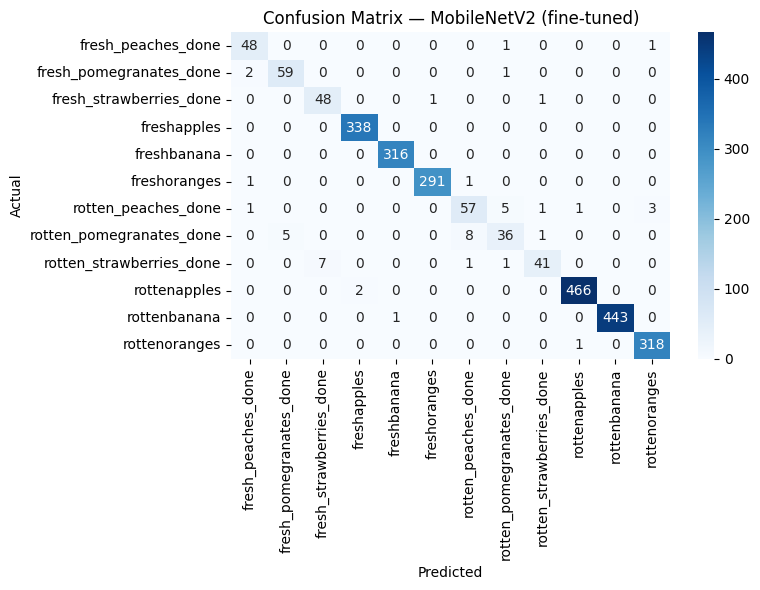

In [13]:
val_gen.reset()
y_pred_probs = tl_model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes
labels = list(val_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — MobileNetV2 (fine-tuned)')
plt.tight_layout()
plt.savefig('outputs_confusion_matrix.png', dpi=150)
plt.show()

## 9. Sample Predictions (correct + misclassified) — for PPT

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


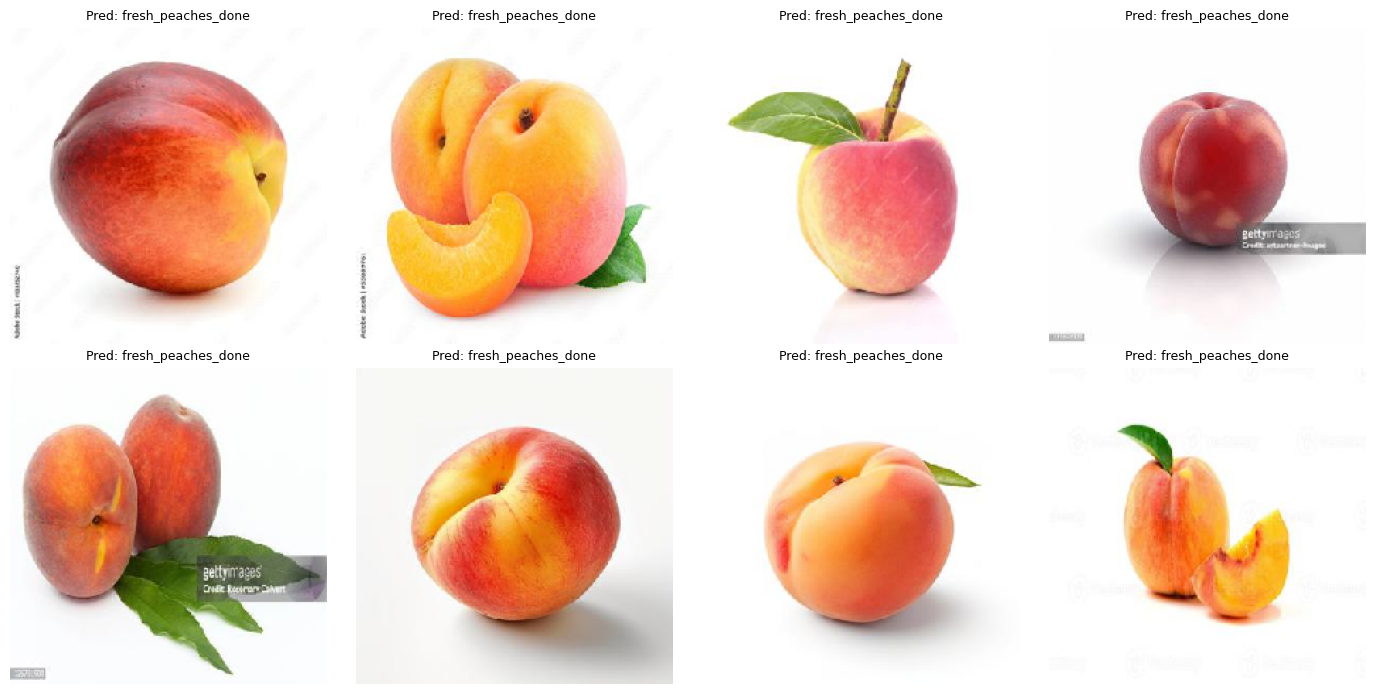

In [14]:
val_gen.reset()
images, _ = next(val_gen)
preds = tl_model.predict(images)
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(2, 4, figsize=(14,7))
for i, ax in enumerate(axes.flatten()):
    if i >= len(images):
        break
    img = (images[i] + 1) / 2.0  # undo mobilenet preprocessing roughly for display
    ax.imshow(img)
    ax.set_title(f'Pred: {labels[pred_labels[i]]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('outputs_sample_predictions.png', dpi=150)
plt.show()

## 10. Save Final Model

In [15]:
tl_model.save('fruit_freshness_mobilenetv2.h5')
print('Model saved.')

Model saved.


## Notes for the PPT
- Report baseline CNN accuracy vs MobileNetV2 accuracy as a direct comparison slide.
- Use `outputs_class_distribution.png`, `outputs_sample_images.png`, `outputs_*_curves.png`, `outputs_confusion_matrix.png`, and `outputs_sample_predictions.png` directly in slides.
- Mention in the presentation: why transfer learning (fewer epochs, better accuracy with limited data/time), and the fine-tuning step (unfreezing last 30 layers) as a value-add over a plain frozen-base approach.